# Introduction to rosace-AA (Python)

This vignette demonstrates **rosaceAA** functionality in the Python `rosace` package.
rosaceAA extends the base ROSACE model with BLOSUM62-based amino acid grouping, enabling
prior information about substitution biochemistry to inform variant effect estimates.

## Four ROSACE models

| Model | Extra structure | Stan data added |
|-------|----------------|-----------------|
| ROSACE0 | None | — |
| ROSACE1 | Position-level grouping | `vMAPp`, `P` |
| ROSACE2 | Position + global BLOSUM group | `vMAPb`, `B` |
| ROSACE3 | Position + BLOSUM + position-specific activation | same as ROSACE2 |

We use simulated OCT1-like data throughout.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rosace.run_rosette import generate_count
from rosace.assay import AssayGrowth, AssaySetGrowth
from rosace.preprocessing import filter_data, impute_data, normalize_data
from rosace.slr import run_slr
from rosace.utils import output_score, map_blosum_score
from rosace.run_rosace import gen_rosace_input


## Data generation

We simulate a deep mutational scanning experiment with 30 positions,
all 19 amino-acid substitutions per position, and 2 replicates × 4 time points.


In [2]:
rng = np.random.default_rng(42)
n_pos = 30
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
wt_residues = rng.choice(amino_acids, size=n_pos)

records = []
for pos_idx, wt in enumerate(wt_residues, 1):
    muts = [aa for aa in amino_acids if aa != wt]
    for mut in muts:
        roll = rng.random()
        if roll < 0.30:
            effect = rng.normal(-1.5, 0.35)
        elif roll < 0.40:
            effect = rng.normal(0.8, 0.2)
        else:
            effect = rng.normal(0.0, 0.1)
        records.append({
            "variant": f"p.{wt}{pos_idx}{mut}",
            "pos": pos_idx, "wt": wt, "mut": mut, "effect": effect
        })
    records.append({
        "variant": f"_wt_{pos_idx}", "pos": pos_idx,
        "wt": wt, "mut": wt, "effect": 0.0
    })

effects = pd.DataFrame(records)
print(f"Total variants: {len(effects)}  (including {(effects['wt']==effects['mut']).sum()} WT controls)")


Total variants: 600  (including 30 WT controls)


In [3]:
count_config = {
    "rounds": 3, "n_reps": 2, "init_count": 200,
    "depth": 500_000, "disp": 0.05, "disp_start": 0.1, "seed": 42
}
counts_df = generate_count(count_config, effects)

wt_names = [v for v in effects['variant'] if v.startswith('_wt_')]
assays = []
for rep in [1, 2]:
    rep_cols = [f'rep_{rep}_t{t}' for t in range(4)]
    mat = counts_df[rep_cols].values.astype(float)
    a = AssayGrowth(
        counts=mat,
        var_names=counts_df['variant'].tolist(),
        key='OCT1sim', rep=rep
    )
    a = filter_data(a)
    a = impute_data(a, method='zero')
    a = normalize_data(a, method='wt', wt_var_names=wt_names, wt_rm=True)
    assays.append(a)

assay1 = assays[0]
print(f"Assay 1 — variants after preprocessing: {len(assay1.norm_var_names)}")

# Build var_info for ROSACE1/2/3 (non-synonymous only; WT variants were removed)
var_info = (
    effects[effects['variant'].isin(assay1.norm_var_names)]
    [['variant', 'pos', 'wt', 'mut']]
    .copy()
    .reset_index(drop=True)
)
print(f"var_info rows: {len(var_info)}")
var_info.head()


Assay 1 — variants after preprocessing: 570
var_info rows: 570


,variant,pos,wt,mut
0,p.C1A,1,C,A
1,p.C1D,1,C,D
2,p.C1E,1,C,E
3,p.C1F,1,C,F
4,p.C1G,1,C,G


## ROSACE Model 0 — no positional structure

The simplest model: each variant gets its own fitness effect with no
position- or amino-acid-level pooling.


In [4]:
data0 = gen_rosace_input(assay1, method='ROSACE0')
print("ROSACE0 Stan data keys:", list(data0.keys()))
print(f"  T={data0['T']}, V={data0['V']}, M={data0['M']}")
print(f"  Time points (t): {data0['t']}")
print(f"  Mean-count groups (vMAPm) first 10: {data0['vMAPm'][:10]}")


ROSACE0 Stan data keys: ['T', 'V', 'M', 'vMAPm', 't', 'm']
  T=4, V=570, M=5
  Time points (t): [0, 1, 2, 3]
  Mean-count groups (vMAPm) first 10: [4, 5, 1, 4, 1, 5, 4, 3, 2, 4]


## ROSACE Model 1 — position-level grouping

`vMAPp` maps each variant to its amino-acid position.  A position-level
hyperprior pools information across variants at the same site.


In [5]:
data1 = gen_rosace_input(assay1, method='ROSACE1', var_info=var_info)
print("ROSACE1 Stan data keys:", list(data1.keys()))
print(f"  T={data1['T']}, V={data1['V']}, M={data1['M']}, P={data1['P']} positions")
print(f"  Position mapping (vMAPp) first 10: {data1['vMAPp'][:10]}")


ROSACE1 Stan data keys: ['T', 'V', 'M', 'vMAPm', 't', 'm', 'P', 'vMAPp']
  T=4, V=570, M=5, P=30 positions
  Position mapping (vMAPp) first 10: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## ROSACE Model 2 — BLOSUM62 amino-acid grouping (rosaceAA)

Model 2 adds a **global** BLOSUM62 substitution-score group (`vMAPb`).
Substitutions with similar BLOSUM62 scores share a hyperprior, encoding
the biochemical expectation that similar substitutions have similar effects.

BLOSUM groups are integers 1–11:
- **Group 11** — synonymous / identity (score ≥ 1, same AA)
- **Groups 1–10** — non-synonymous substitutions binned from most negative
  (group 1) to neutral/positive (group 10) BLOSUM62 score


In [6]:
data2 = gen_rosace_input(assay1, method='ROSACE2', var_info=var_info)
print("ROSACE2 Stan data keys:", list(data2.keys()))
print(f"  T={data2['T']}, V={data2['V']}, M={data2['M']}")
print(f"  P={data2['P']} positions, B={data2['B']} BLOSUM groups")
print(f"  BLOSUM mapping (vMAPb) first 10: {data2['vMAPb'][:10]}")

group_counts = collections.Counter(data2['vMAPb'])
print("\nBLOSUM group distribution:")
for g in sorted(group_counts):
    bar = "█" * (group_counts[g] // 5)
    print(f"  Group {g:2d}: {group_counts[g]:4d}  {bar}")


ROSACE2 Stan data keys: ['T', 'V', 'M', 'vMAPm', 't', 'm', 'P', 'vMAPp', 'B', 'vMAPb']
  T=4, V=570, M=5
  P=30 positions, B=11 BLOSUM groups
  BLOSUM mapping (vMAPb) first 10: [5, 2, 1, 3, 2, 2, 4, 2, 4, 4]

BLOSUM group distribution:
  Group  1:   15  ███
  Group  2:  118  ███████████████████████
  Group  3:  130  ██████████████████████████
  Group  4:  164  ████████████████████████████████
  Group  5:   74  ██████████████
  Group  6:   44  ████████
  Group  7:   21  ████
  Group  8:    4  


## BLOSUM62 substitution-group heatmap

The heatmap below shows which BLOSUM62 group is assigned to every
wildtype → mutant amino acid pair.  Diagonal cells (synonymous) are always
group 11.


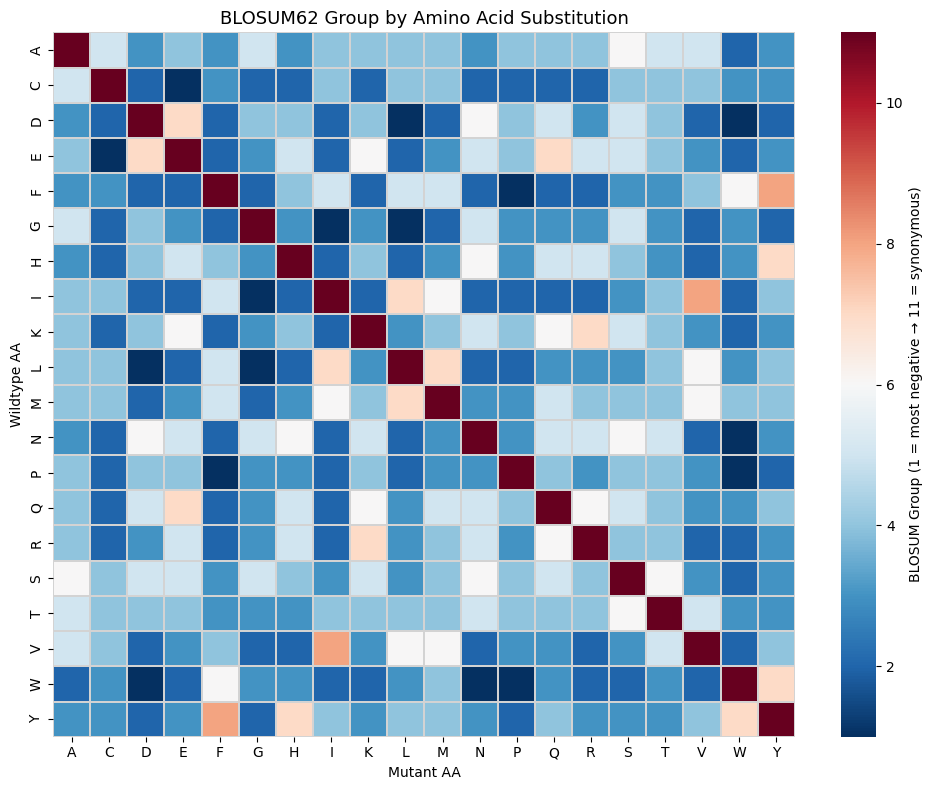

In [7]:
rows = []
for wt in amino_acids:
    for mut in amino_acids:
        rows.append({'wt': wt, 'mut': mut, 'BLOSUM_group': map_blosum_score(wt, mut)})
blosum_df = pd.DataFrame(rows)
pivot = blosum_df.pivot(index='wt', columns='mut', values='BLOSUM_group')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot, cmap='RdBu_r', center=6, vmin=1, vmax=11, ax=ax,
    linewidths=0.3, linecolor='lightgrey',
    cbar_kws={'label': 'BLOSUM Group (1 = most negative → 11 = synonymous)'}
)
ax.set_title('BLOSUM62 Group by Amino Acid Substitution', fontsize=13)
ax.set_xlabel('Mutant AA')
ax.set_ylabel('Wildtype AA')
plt.tight_layout()
plt.show()


## SLR scores stratified by BLOSUM62 group

We run simple linear regression (SLR) on assay 1, then annotate each
variant's BLOSUM62 group and visualise how average fitness scores vary
across groups.  Group 11 (synonymous) should cluster near zero.


In [8]:
score_obj = run_slr(assay1)
scores = output_score(score_obj)
print(f"Scored variants: {len(scores)}")
scores.head()


Scored variants: 570


,variant,mean,sd,lfsr,label
0,p.C1A,-1.202889,0.188948,9.686133e-11,Neg
1,p.C1D,-1.955258,0.314741,2.611299e-10,Neg
2,p.C1E,0.037117,0.072567,3.045072e-01,Neutral
3,p.C1F,1.016649,0.086926,6.708895e-32,Pos
4,p.C1G,0.028244,0.063469,3.281576e-01,Neutral


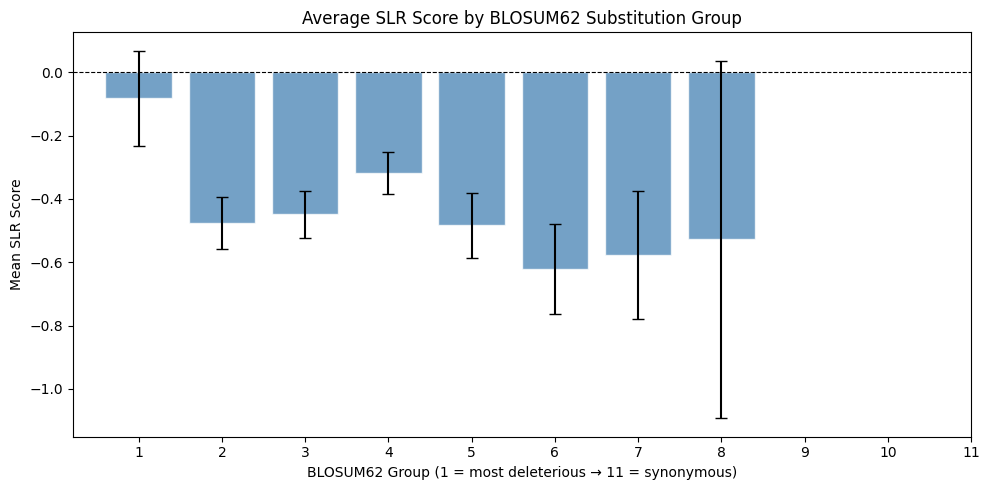

In [9]:
scores_blosum = scores.merge(var_info, on='variant', how='left')
scores_blosum['blosum_group'] = scores_blosum.apply(
    lambda r: map_blosum_score(str(r['wt']), str(r['mut']))
              if pd.notna(r['wt']) and pd.notna(r['mut']) else np.nan,
    axis=1
)

blosum_means = (
    scores_blosum
    .dropna(subset=['blosum_group'])
    .groupby('blosum_group')['mean']
    .agg(['mean', 'sem'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    blosum_means['blosum_group'], blosum_means['mean'],
    yerr=blosum_means['sem'],
    color='steelblue', alpha=0.75, capsize=4, edgecolor='white'
)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('BLOSUM62 Group (1 = most deleterious → 11 = synonymous)')
ax.set_ylabel('Mean SLR Score')
ax.set_title('Average SLR Score by BLOSUM62 Substitution Group')
ax.set_xticks(range(1, 12))
plt.tight_layout()
plt.show()


## Model comparison summary

| Model | Key parameters added | When to use |
|-------|---------------------|-------------|
| **ROSACE0** | — | Quick baseline, no positional context |
| **ROSACE1** | `P`, `vMAPp` | Gene-wide positional pooling |
| **ROSACE2** | `P`, `vMAPp`, `B`, `vMAPb` | + global BLOSUM biochemical prior |
| **ROSACE3** | same as ROSACE2 | + position-specific activation (richer) |

**Key take-away**: rosaceAA (models 2 and 3) encodes the prior belief that
substitutions with similar BLOSUM62 scores have similar functional effects.
This is particularly beneficial when data are sparse, as information is shared
across biochemically similar substitutions even at different positions.

To run full Bayesian inference, pass the Stan data dictionary from
`gen_rosace_input()` to `run_rosace()` (requires CmdStan to be installed).
